In [1]:
"""
    Code to analyze OR sensitivity to nonuniform PGS effects
    Supplemental Figure S3
"""

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from scipy.special import expit
from scipy.stats import norm

import util.util as util
import util.pre_process as pre
import util.bootstrap_tools as btool
from scipy.stats import skewnorm

import time

import matplotlib.pyplot as plt

n_runs = 100

n_samps_ls = [40000, 100000, 350000]
prev = .05
n_covars = 16
top_pgs = .03
pgs_thresh = norm.ppf(1-top_pgs)
odds_ratio = 2.0

nonlin_ls = [0, .1, .25, .5, .75]

n_samps_strata_ls = [1000, 2500, 5000, 10000, 25000, 50000]

# Run simulations

In [2]:
import torch

def skew_normal(alpha, shape, device=None):
    delta = alpha / torch.sqrt(1 + alpha**2)
    z0 = torch.randn(shape, device=device)
    z1 = torch.randn(shape, device=device)
    return delta * torch.abs(z0) + torch.sqrt(1 - delta**2) * z1

def find_intercept(target_prev, beta_pgs, pgs):
    lo = torch.tensor(-5.0)
    hi = torch.tensor(0)
    for _ in range(60):
        mid = (lo + hi) * 0.5
        p = torch.special.expit(mid + beta_pgs * pgs).mean()
        hi = torch.where(p > target_prev, mid, hi)
        lo = torch.where(p <= target_prev, mid, lo)
    return (lo + hi) * 0.5

print('Find Beta and Intercept')
beta_pgs = []
intercept = []
for nonlin_ in nonlin_ls:
    pgs = skew_normal(torch.tensor(0, dtype=torch.float32), (5000000,))
    pgs = (pgs - pgs.mean()) / pgs.std()
    
    thresh = torch.quantile(pgs, 1 - top_pgs)

    pgs_nonlin = pgs*(nonlin_*torch.nn.functional.softplus(pgs)+1)
    #r = torch.argsort(torch.argsort(pgs))
    #pgs_nonlin = pgs + nonlin_ * r.float() / pgs.numel()
    mu_hi = (pgs_nonlin[pgs > thresh]).mean()
    mu_lo = (pgs_nonlin[pgs <= thresh]).mean()
    beta_pgs_ = torch.log(torch.tensor(odds_ratio)) / (mu_hi - mu_lo)
    
    beta_pgs.append(beta_pgs_.item())
    
    intercept_ = find_intercept(prev, beta_pgs_, pgs)
    intercept.append(intercept_.item())

Find Beta and Intercept


In [ ]:
import time
N_JOBS = 32

print('Run Simulations')
pain = np.full((len(n_samps_ls), len(nonlin_ls), len(n_samps_strata_ls), n_runs), np.nan)
subset = np.full_like(pain, np.nan)
inter = np.full_like(pain, np.nan)
inter_inter = np.full_like(pain, np.nan)
for i_samps, n_samps in enumerate(n_samps_ls):
    for i_nonlin, nonlin in enumerate(nonlin_ls):

        if i_samps != 2:
            continue

        if i_nonlin != 2:
            continue
        
        beta_pgs_ = beta_pgs[i_nonlin]
        intercept_ = intercept[i_nonlin]
        
        pgs = skew_normal(torch.tensor(0, dtype=torch.float32), (n_runs, n_samps))
        pgs = (pgs-pgs.mean(1, keepdim=True))/pgs.std(1, keepdim=True)

        covars = torch.randn(n_runs, n_samps, n_covars+3)
        covars[:,:,:3] = 0

        prob = torch.special.expit(intercept_ + beta_pgs_ * pgs * (nonlin*torch.nn.functional.softplus(pgs)+1))
        #pgs_ranked = torch.argsort(torch.argsort(pgs, dim=0), dim=0).float()/n_samps
        #prob = torch.special.expit(intercept_ + beta_pgs_*(pgs + nonlin*pgs_ranked))
        phen = (torch.rand(n_runs, n_samps) < prob).float()

        phen_res = btool.efficient_linear_regression(covars[:,:,3:].numpy(), phen.numpy())['residuals']
        pgs_res = btool.efficient_linear_regression(covars[:,:,3:].numpy(), pgs.numpy())['residuals']

        t0 = time.time()
        for i_samps_strata, n_samps_strata in enumerate(n_samps_strata_ls):
            if (n_samps_strata >= n_samps):
                continue
            
            covars[:,:,3:] = 0
            
            pgs_ = pgs[:,:n_samps_strata]
            phen_ = phen[:,:n_samps_strata]
            prev_ = phen_.mean(1)

            phen_res_ = phen_res[:,:n_samps_strata]
            pgs_res_ = pgs_res[:,:n_samps_strata]

            pgs_thresh = torch.quantile(pgs_, 1 - top_pgs, dim=1, keepdim=True)
            high_pgs = (pgs > pgs_thresh)

            covars[:,:,2] = high_pgs
            covars[:,:n_samps_strata,1] = high_pgs[:, :n_samps_strata]
            covars[:,:n_samps_strata, 0] = 1
            
            # Pain et al Method
            r2_obs = btool.efficient_r2(pgs_res_, phen_res_)['r2']
            pain_ = btool.effecient_r2_to_risk(r2_obs, prev_.numpy(), top_pgs, None)['odds_ratio']
            pain[i_samps, i_nonlin, i_samps_strata, :] = pain_

            # Subset Method
            subset_params = btool.efficient_logistic_regression(covars[:,:n_samps_strata,2:], phen_, fetch_params=['weights'], n_jobs=N_JOBS)['weights']
            subset_or = np.exp(subset_params[:,0])
            subset[i_samps, i_nonlin, i_samps_strata, :] = subset_or

            # Interaction Method
            inter_params = btool.efficient_logistic_regression(covars[:,:,1:], phen, fetch_params=['weights'], n_jobs=N_JOBS)['weights']
            inter_or = np.exp(inter_params[:,0] + inter_params[:,1])
            inter[i_samps, i_nonlin, i_samps_strata, :] = inter_or

            # Interaction^2 Method
            inter_inter_params = btool.efficient_logistic_regression(covars, phen, fetch_params=['weights'], n_jobs=N_JOBS)['weights']
            inter_inter_or = np.exp(inter_inter_params[:,1] + inter_inter_params[:,2])
            inter_inter[i_samps, i_nonlin, i_samps_strata, :] = inter_inter_or
            
            print(f"# of Samps: {n_samps}, NonLine: {nonlin}, Strata: {n_samps_strata}, TIME: {(time.time() - t0)/60}")
    
        np.save("results/pain_nonlin.npy", pain)
        np.save("results/subset_nonlin.npy", subset)
        np.save("results/inter_nonlin.npy", inter)
        np.save("results/inter_inter_nonlin.npy", inter_inter)


# Load Files

In [3]:
pain = np.load("results/pain_nonlin.npy")
subset = np.load("results/subset_nonlin.npy")
inter = np.load("results/inter_nonlin.npy")
inter_inter = np.load("results/inter_inter_nonlin.npy")

# Plot figures

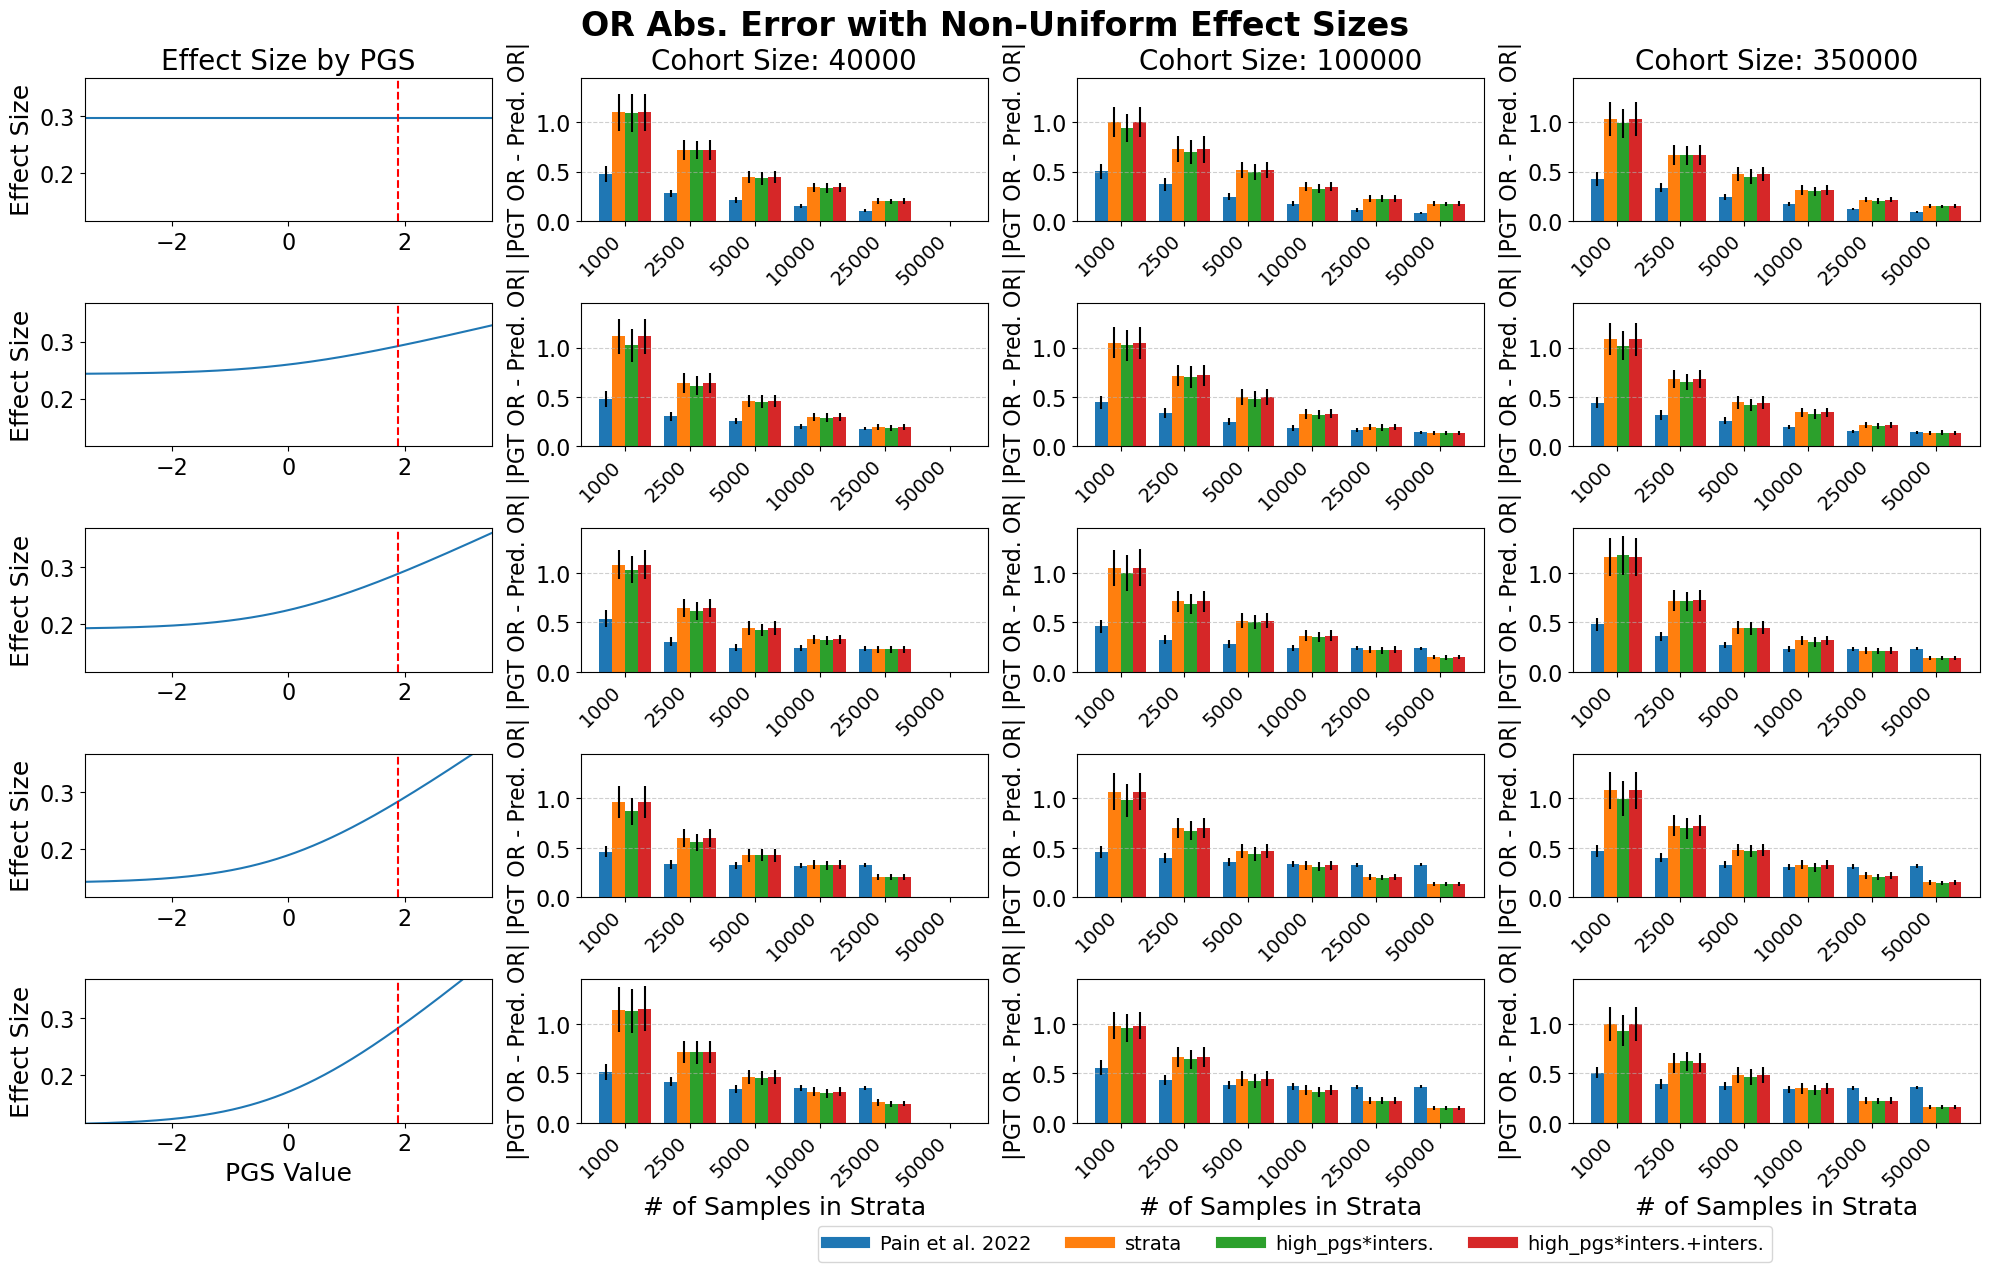

In [5]:
from scipy.stats import gaussian_kde, norm
import seaborn as sns

fig, axs = plt.subplots(len(nonlin_ls), 1+len(n_samps_ls), figsize=(20, 2.5*len(nonlin_ls)))


# track y-limits for all non-first-column plots
ys = [ beta_pgs[i_nonlin]*(nonlin * torch.nn.functional.softplus(torch.linspace(-3, 3, 500)) + 1) for i_nonlin, nonlin in enumerate(nonlin_ls) ]
ymin = min([y.min().item() for y in ys])
ymax = max([y.max().item() for y in ys])

for i_nonlin, nonlin in enumerate(nonlin_ls):
    x = torch.linspace(-3.5, 3.5, 500)
    y = (nonlin * torch.nn.functional.softplus(x) + 1)*beta_pgs[i_nonlin]

    axs[i_nonlin, 0].plot(x.numpy(), y.numpy())
    axs[i_nonlin, 0].set_xlim(-3.5, 3.5)
    axs[i_nonlin, 0].set_ylim(ymin, ymax)
    axs[i_nonlin, 0].axvline(norm.ppf(1 - top_pgs), linestyle='--', color='red')
    axs[i_nonlin,0].set_ylabel("Effect Size", fontsize=18)

ymins = []
ymaxs = []

pain_label = ["Pain et al. 2022", "strata", "high_pgs*inters.", "high_pgs*inters.+inters."]
for i_samps, n_samps in enumerate(n_samps_ls):
    for i_nonlin, nonlin in enumerate(nonlin_ls):
        pain_diff = abs(pain[i_samps, i_nonlin]-odds_ratio)
        strata_diff = abs(subset[i_samps, i_nonlin]-odds_ratio)
        inter_diff = abs(inter[i_samps, i_nonlin]-odds_ratio)
        inter_inter_diff = abs(inter_inter[i_samps, i_nonlin]-odds_ratio)
        
        means = [pain_diff.mean(1), strata_diff.mean(1), inter_diff.mean(1), inter_inter_diff.mean(1)]

        cis = [
            1.96 * abs(pain[i_samps, i_nonlin]-odds_ratio).std(1) / np.sqrt(n_runs),
            1.96 * abs(subset[i_samps, i_nonlin]-odds_ratio).std(1) / np.sqrt(n_runs),
            1.96 * abs(inter[i_samps, i_nonlin]-odds_ratio).std(1) / np.sqrt(n_runs),
            1.96 * abs(inter_inter[i_samps, i_nonlin]-odds_ratio).std(1) / np.sqrt(n_runs)
        ]
        x = np.arange(len(n_samps_strata_ls))
        width = 0.2
        axs[i_nonlin, i_samps+1].bar(x - 1.5*width, means[0], width, yerr=cis[0], label=pain_label[0])
        axs[i_nonlin, i_samps+1].bar(x - 0.5*width, means[1], width, yerr=cis[1], label=pain_label[1])
        axs[i_nonlin, i_samps+1].bar(x + 0.5*width, means[2], width, yerr=cis[2], label=pain_label[2])
        axs[i_nonlin, i_samps+1].bar(x + 1.5*width, means[3], width, yerr=cis[3], label=pain_label[3])
        axs[i_nonlin, i_samps+1].set_xticks(x)
        axs[i_nonlin, i_samps+1].set_xticklabels([str(v) for v in n_samps_strata_ls])
        #axs[i_nonlin, i_samps+1].legend(fontsize=11, loc='upper right')

        ymin, ymax = axs[i_nonlin, 1].get_ylim()
        ymins.append(ymin)
        ymaxs.append(ymax)

# apply shared y-axis to all columns except first
shared_min = min(ymins)
shared_max = max(ymaxs)

axs[-1,0].set_xlabel("PGS Value", fontsize=18)

for i in range(1, len(nonlin_ls)):
    axs[i,0].sharex(axs[0,0])

for j in range(1, 1+len(n_samps_ls)):
    axs[-1,j].set_xlabel("# of Samples in Strata", fontsize=18)
    for i in range(len(nonlin_ls)):
        axs[i,j].tick_params(axis='x', labelrotation=45, labelsize=14)
        for t in axs[i,j].get_xticklabels():
            t.set_ha("right")
        axs[i,j].tick_params(axis='y', labelsize=16)
        axs[i,j].set_ylabel("|PGT OR - Pred. OR|", fontsize=16)
        

for i in range(len(nonlin_ls)):
    axs[i,0].tick_params(axis='both', labelsize=16)

for i in range(len(nonlin_ls)):
    for j in range(1, 1+len(n_samps_ls)):
        axs[i, j].set_ylim(shared_min, shared_max)
        axs[i, j].grid(axis='y', linestyle='--', alpha=0.6)

col_titles = ["Effect Size by PGS", "Cohort Size: 40000", "Cohort Size: 100000", "Cohort Size: 350000"]
for j, title in enumerate(col_titles):
    axs[0, j].set_title(title, fontsize=20)

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color='C0', lw=8),
    Line2D([0], [0], color='C1', lw=8),
    Line2D([0], [0], color='C2', lw=8),
    Line2D([0], [0], color='C3', lw=8),
]

fig.legend(
    handles=handles,
    labels=pain_label,
    loc="lower center",
    bbox_to_anchor=(.65, -0.03 ),
    ncol=4,
    fontsize=14
)

fig.suptitle("OR Abs. Error with Non-Uniform Effect Sizes", fontsize=24, fontweight='bold')

plt.tight_layout()
plt.savefig("nonlin.png", dpi=150, bbox_inches="tight")
plt.show()

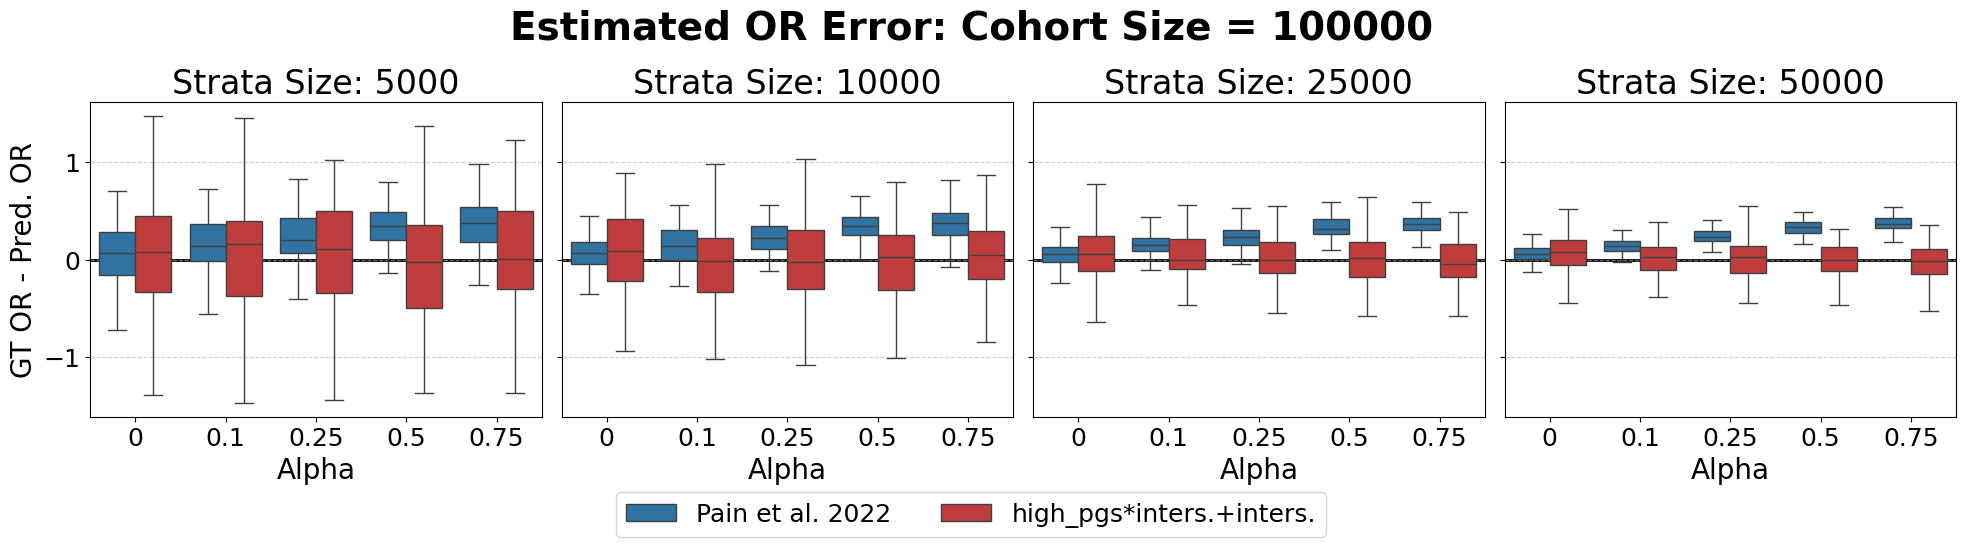

In [6]:
fig2, axs2 = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

strata_targets = [5000, 10000, 25000, 50000]
pop_idx = n_samps_ls.index(100000)

all_handles = None
all_labels = None

for ax_idx, strata_val in enumerate(strata_targets):
    strata_pos = n_samps_strata_ls.index(strata_val)

    flat_data = []
    skew_groups = []
    method_groups = []

    for i_nonlin, nonlin in enumerate(nonlin_ls):
        boot_pain = odds_ratio - pain[pop_idx, i_nonlin][strata_pos] 
        flat_data.extend(boot_pain)
        skew_groups.extend([f"{nonlin}"] * boot_pain.shape[0])
        method_groups.extend(["Pain et al. 2022"] * boot_pain.shape[0])

        boot_last = odds_ratio - inter_inter[pop_idx, i_nonlin][strata_pos]
        flat_data.extend(boot_last)
        skew_groups.extend([f"{nonlin}"] * boot_last.shape[0])
        method_groups.extend(["high_pgs*inters.+inters."] * boot_last.shape[0])

    sns.boxplot(
        x=skew_groups,
        y=flat_data,
        hue=method_groups,
        palette=["C0", "C3"],
        showfliers=False,
        ax=axs2[ax_idx]
    )

    if ax_idx == 0:
        h, l = axs2[ax_idx].get_legend_handles_labels()
        all_handles, all_labels = h, l

    axs2[ax_idx].legend_.remove()

    axs2[ax_idx].set_xlabel("Alpha", fontsize=20)
    axs2[ax_idx].set_ylabel("GT OR - Pred. OR", fontsize=20)
    axs2[ax_idx].set_title(f"Strata Size: {strata_val}", fontsize=24)
    axs2[ax_idx].tick_params(axis='x', labelsize=18)
    axs2[ax_idx].tick_params(axis='y', labelsize=18)
    axs2[ax_idx].grid(axis='y', linestyle='--', alpha=0.6)

    axs2[ax_idx].axhline(0, color='black', linewidth=2, zorder=0)

fig2.legend(
    handles=all_handles,
    labels=all_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    fontsize=18
)

fig2.suptitle("Estimated OR Error: Cohort Size = 100000", fontsize=28, fontweight='bold')

plt.tight_layout()
plt.savefig("nonlin_error.png", dpi=150, bbox_inches="tight")
plt.show()